<a href="https://colab.research.google.com/github/tofighi/tutorials/blob/master/AI/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks

Welcome to the Neural Networks module. This notebook is designed for both undergraduate and graduate students and is split into four parts:
* **Part 1: Basic Neural Network Concepts** — ANN, Perceptron, Activation Functions, and ML Terms.
* **Part 2: Neural Network Architecture & Advanced Concepts** — ANN Architecture, Shallow vs Deep, DL Algorithm, Black Box Problem.
* **Part 3: Loss Functions & Optimization Algorithms** — MSE, Cross-Entropy, KL Divergence, Gradient Descent, Backpropagation.
* **Part 4: Code for Neural Networks** — Activation Functions, Scikit-Learn MLP, Keras Neural Network.

## Table of Contents
* [Part 1: Basic Neural Network Concepts](#part_1)
  * [1.1 Artificial Neural Network (ANN) & Perceptron Model](#section_1_1)
  * [1.2 Activation Functions (ReLU, Sigmoid, Softmax)](#section_1_2)
  * [1.3 Machine Learning Terms](#section_1_3)
* [Part 2: Neural Network Architecture & Advanced Concepts](#part_2)
  * [2.1 ANN Architecture](#section_2_1)
  * [2.2 Difference Between Shallow and Deep Neural Networks](#section_2_2)
  * [2.3 Deep Learning (DL) Algorithm & Black Box Problem](#section_2_3)
* [Part 3: Loss Functions & Optimization Algorithms](#part_3)
  * [3.1 Cost Functions: MSE, Cross-Entropy, KL Divergence](#section_3_1)
  * [3.2 Gradient Descent (GD) and Backpropagation](#section_3_2)
  * [3.3 Epochs and Batches](#section_3_3)
* [Part 4: Code for Neural Networks](#part_4)
  * [4.1 Plotting Activation Functions](#section_4_1)
  * [4.2 Basic MLP with Scikit-Learn](#section_4_2)
  * [4.3 Deep MLP and Learning Curves](#section_4_3)
  * [4.4 Keras Neural Network for Iris Classification](#section_4_4)

<a name="part_1"></a>
# Part 1: Basic Neural Network Concepts

<a name="section_1_1"></a>
### 1.1 Artificial Neural Network (ANN) & Perceptron Model
An **Artificial Neural Network (ANN)** is a computational model inspired by the structure of biological neural networks in the human brain. ANNs are designed to recognize patterns and make decisions by learning from data.

The simplest building block of an ANN is the **Perceptron Model** (a single "neuron"). It takes multiple inputs, multiplies each by a corresponding weight, adds a bias term, and passes the sum through an activation function to produce an output.

<img src="https://raw.githubusercontent.com/tofighi/tutorials/refs/heads/master/AI/Images/single-neuron.svg" width="400">

Mathematically, a single neuron computes:
$$z = \sum_{i=1}^{n} W_i x_i + b = W_1 x_1 + W_2 x_2 + \cdots + W_n x_n + b$$
$$\hat{y} = f(z)$$
where $f$ is the activation function.

**Numerical Example:**
Suppose a perceptron has two inputs $x_1 = 0.5, x_2 = -1.0$, with weights $W_1 = 2.0, W_2 = 1.0$, and bias $b = 0.5$.
The linear combination is:
$$z = W_1 x_1 + W_2 x_2 + b = (2.0)(0.5) + (1.0)(-1.0) + 0.5 = 1.0 - 1.0 + 0.5 = 0.5$$

<a name="section_1_2"></a>
### 1.2 Activation Functions (ReLU, Sigmoid, Softmax)
Activation functions introduce non-linearity into the network, enabling it to learn complex patterns.

* **Sigmoid**: $f(z) = \frac{1}{1 + e^{-z}}$ — Outputs a value between 0 and 1. Commonly used in binary classification output layers.
* **Rectified Linear Unit (ReLU)**: $f(z) = \max(0, z)$ — Outputs $z$ if positive, else $0$. The most popular activation for hidden layers in deep networks.
* **Softmax**: $f(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$ — Converts a vector of raw scores into a probability distribution over $K$ classes. Used in the output layer for multi-class classification.

*(Note: The Python code to plot these activation functions can be found in [Section 4.1](#section_4_1).)*

**Numerical Example (Sigmoid & ReLU):**
Using $z = 0.5$ from the previous example:
- ReLU output: $f(0.5) = \max(0, 0.5) = 0.5$.
- Sigmoid output: $f(0.5) = \frac{1}{1 + e^{-0.5}} \approx 0.622$.

**Numerical Example (Softmax - Iris Classification):**
Assume Softmax Regression is used to classify Iris to Setosa (1), Versicolor (2), or Virginica (3) using petal length ($x_1$) and petal width ($x_2$).
<img src="https://raw.githubusercontent.com/tofighi/tutorials/refs/heads/master/AI/Images/softmax-example.svg" width="400">

1) **Weight vectors and class probabilities:**
If all weights and biases are initialized to 0.5, the linear combination for each class $k \in \{1, 2, 3\}$ is:
$$z_k = W_1^{(k)} x_1 + W_2^{(k)} x_2 + b^{(k)} = 0.5 x_1 + 0.5 x_2 + 0.5$$
The probability for each class is calculated using Softmax:
$$P(y=k | x) = \frac{e^{z_k}}{e^{z_1} + e^{z_2} + e^{z_3}}$$

2) **Classification result for a new iris ($x_1 = 4.5, x_2 = 1.6$):**
- $z_1 = 0.5(4.5) + 0.5(1.6) + 0.5 = 2.25 + 0.8 + 0.5 = 3.55$
- $z_2 = 3.55$
- $z_3 = 3.55$
Since all $z_k$ are equal, $e^{z_k}$ is equal for all classes.
$$P(y=k | x) = \frac{e^{3.55}}{e^{3.55} + e^{3.55} + e^{3.55}} = \frac{1}{3} \approx 33.3\%$$
The predicted class is undecided (equal probability).

3) **Changing weights for class 1 (Setosa) to 1:**
- $z_1 = 1(4.5) + 1(1.6) + 1 = 4.5 + 1.6 + 1 = 7.1$
- $z_2 = 3.55$
- $z_3 = 3.55$
Probabilities:
- $e^{z_1} = e^{7.1} \approx 1211.96$
- $e^{z_2} = e^{3.55} \approx 34.81$
- $e^{z_3} = e^{3.55} \approx 34.81$
- Sum $= 1211.96 + 34.81 + 34.81 = 1281.58$
$$P(Class 1) = \frac{1211.96}{1281.58} \approx 94.57\%$$
The predicted class is **Class 1 (Setosa)** with 94.57% probability.

<a name="section_1_3"></a>
### 1.3 Machine Learning Terms
* **Sample**: A single row of data (also called an instance, observation, or feature vector).
* **Model Parameter**: An internal configuration variable learned from data (e.g., weights $W$ and biases $b$).
* **Model Hyperparameter**: An external configuration variable set by the practitioner before training (e.g., learning rate $\alpha$, number of hidden layers, number of neurons per layer).

**Numerical Example:**
In the neuron example above, $W_1=2.0, W_2=1.0$, and $b=0.5$ are **Model Parameters** (learned during training). If we choose a learning rate $\alpha = 0.01$, that is a **Model Hyperparameter** (set before training begins).

<a name="part_2"></a>
# Part 2: Neural Network Architecture & Advanced Concepts

<a name="section_2_1"></a>
### 2.1 ANN Architecture
The architecture of an ANN defines how neurons are organized into layers:
* **Input Layer**: Receives the raw data features. The number of neurons equals the number of input features.
* **Hidden Layer(s)**: Intermediate layers that transform inputs into higher-level representations. Each neuron applies weights, bias, and an activation function.
* **Output Layer**: Produces the final prediction. For classification, the number of output neurons typically equals the number of classes.

<img src="https://raw.githubusercontent.com/tofighi/tutorials/refs/heads/master/AI/Images/one-hidden-layer-network.svg" width="400">

**Numerical Example (Forward Propagation - Shallow Network):**
Consider a tiny network: 1 input ($x_1=2$), one hidden neuron ($W^{(1)}=1.5$, $b^{(1)}=0$), and one output neuron ($W^{(2)}=2.0$, $b^{(2)}=-1$). Using ReLU:
1. Hidden neuron: $z^{(1)} = (1.5)(2) + 0 = 3$. Activation: $a^{(1)} = \max(0, 3) = 3$.
2. Output neuron: $z^{(2)} = (2.0)(3) - 1 = 5$. Activation: $a^{(2)} = \max(0, 5) = 5$.
The network output is **5**.

<br>
<img src="https://raw.githubusercontent.com/tofighi/tutorials/refs/heads/master/AI/Images/deep-multi-output-network.svg" width="400">

**Numerical Example (Feedforward for Deep Network):**
Based on the figure above, we have 2 inputs, 2 hidden layers (with 3 neurons each), and 2 outputs. Assume:
- Input: $x = [1, 2]$
- If we assume all weights are $1$ and all biases are $0$, using the ReLU activation function:
1. **Hidden Layer 1:** $z^{(1)} = W^{(1)} x + b^{(1)}$. Each neuron computes $1(1) + 1(2) = 3$. Activation $a^{(1)} = \text{ReLU}([3, 3, 3]^T) = [3, 3, 3]^T$.
2. **Hidden Layer 2:** $z^{(2)} = W^{(2)} a^{(1)} + b^{(2)}$. Each neuron computes $1(3) + 1(3) + 1(3) = 9$. Activation $a^{(2)} = \text{ReLU}([9, 9, 9]^T) = [9, 9, 9]^T$.
3. **Output Layer:** $z^{(3)} = W^{(3)} a^{(2)} + b^{(3)}$. Each neuron computes $1(9) + 1(9) + 1(9) = 27$.
The output of the network is $y = [27, 27]^T$.

<a name="section_2_2"></a>
### 2.2 Difference Between Shallow and Deep Neural Networks

<style>
  .custom-table {
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 15px;
  }
  .custom-table th, .custom-table td {
    border: 1px solid #cccccc;
    text-align: left;
    padding: 8px;
  }
  .custom-table tr:nth-child(even) {
    background-color: #f2f2f2;
  }
  @media (prefers-color-scheme: dark) {
    .custom-table th, .custom-table td {
        border-color: #555555;
    }
    .custom-table tr:nth-child(even) {
        background-color: #2c2c2c;
    }
  }
</style>

<table class="custom-table">
  <tr>
    <th>Feature</th>
    <th>Shallow Network</th>
    <th>Deep Network</th>
  </tr>
  <tr>
    <td>Hidden Layers</td>
    <td>1–2</td>
    <td>3 or more (can be hundreds)</td>
  </tr>
  <tr>
    <td>Complexity</td>
    <td>Limited pattern recognition</td>
    <td>Learns hierarchical features</td>
  </tr>
  <tr>
    <td>Training</td>
    <td>Faster, less data needed</td>
    <td>Slower, requires more data</td>
  </tr>
  <tr>
    <td>Example Use</td>
    <td>Simple classification</td>
    <td>Image recognition, NLP</td>
  </tr>
</table>

* **Shallow Neural Network**: Contains only one or two hidden layers. Easier to train but limited in learning highly complex, hierarchical patterns.
* **Deep Neural Network**: Contains many hidden layers. Can learn increasingly abstract representations (e.g., pixels → edges → shapes → objects in image recognition).

**Numerical Example:**
A shallow network for Iris classification: `[Input: 4] → [Hidden: 5] → [Output: 3]` — Total parameters: $(4 \times 5 + 5) + (5 \times 3 + 3) = 43$.
A deep network for digit recognition: `[Input: 64] → [Hidden1: 50] → [Hidden2: 50] → [Hidden3: 25] → [Output: 10]` — Total parameters: $(64 \times 50+50) + (50 \times 50+50) + (50 \times 25+25) + (25 \times 10+10) = 6{,}985$.

<a name="section_2_3"></a>
### 2.3 Deep Learning (DL) Algorithm & Black Box Problem
A **Deep Learning (DL) Algorithm** trains deep neural networks to automatically extract high-level features from raw data, eliminating the need for manual feature engineering. Examples include Convolutional Neural Networks (CNNs) for images and Recurrent Neural Networks (RNNs) for sequential data.

**The Black Box Problem**: Deep learning models can have millions of parameters, making their internal decision-making process opaque. It is difficult to explain *why* the model made a specific prediction. This is a significant concern in domains like healthcare and finance where interpretability is critical. Research fields like **Explainable AI (XAI)** aim to address this limitation.

<a name="part_3"></a>
# Part 3: Loss Functions & Optimization Algorithms

<a name="section_3_1"></a>
### 3.1 Cost Functions: MSE, Cross-Entropy, KL Divergence
Cost (or loss) functions measure how far the network's predictions are from the true values.

**Mean Squared Error (MSE)** — Used for regression tasks:
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Cross-Entropy Loss** — Used for classification tasks:
$$\text{Cross-Entropy} = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$
where $y_i$ is the true label (one-hot encoded) and $\hat{y}_i$ is the predicted probability for class $i$.

**KL Divergence (Kullback-Leibler)** — Measures how one probability distribution $P$ diverges from a reference distribution $Q$:
$$D_{KL}(P \| Q) = \sum_{i} P(i) \log \frac{P(i)}{Q(i)}$$
It is often used when we want to approximate a true, complex distribution $P$ with a simpler, modeled distribution $Q$. A KL divergence of 0 indicates that the two distributions are identical. It is non-symmetric, meaning $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$. In machine learning, minimizing Cross-Entropy is mathematically equivalent to minimizing the KL divergence between the empirical distribution of the training data and the model's predicted distribution.

**Numerical Example (KL Divergence):**
Suppose we have a true distribution $P = [0.2, 0.8]$ and a predicted distribution $Q = [0.4, 0.6]$.
$$D_{KL}(P \| Q) = 0.2 \log_e\left(\frac{0.2}{0.4}\right) + 0.8 \log_e\left(\frac{0.8}{0.6}\right)$$
$$= 0.2(-0.693) + 0.8(0.287) = -0.1386 + 0.2296 = 0.091$$
The value $0.091$ represents the "information lost" when $Q$ is used to approximate $P$.

**Numerical Example (MSE):**
Suppose we have 3 samples with true values $y = [1.0, 2.0, 3.0]$ and predictions $\hat{y} = [0.8, 2.5, 2.7]$.
$$\text{MSE} = \frac{(1.0-0.8)^2 + (2.0-2.5)^2 + (3.0-2.7)^2}{3} = \frac{0.04 + 0.25 + 0.09}{3} = \frac{0.38}{3} \approx 0.127$$

**Numerical Example (Cross-Entropy):**
For a single sample with true class = Class 2 (one-hot: $[0, 1, 0]$) and predicted probabilities $\hat{y} = [0.1, 0.7, 0.2]$:
$$\text{CE} = -(0 \cdot \log(0.1) + 1 \cdot \log(0.7) + 0 \cdot \log(0.2)) = -\log(0.7) \approx 0.357$$

<a name="section_3_2"></a>
### 3.2 Gradient Descent (GD) and Backpropagation
**Gradient Descent (GD)** is an iterative optimization algorithm that updates the network's weights in the opposite direction of the gradient to minimize the cost function:
$$W_{new} = W_{old} - \alpha \frac{\partial J}{\partial W}$$
where $\alpha$ is the learning rate and $J$ is the cost function.

**Backpropagation** is an efficient algorithm that computes the gradient of the cost function with respect to every weight in the network. It uses the chain rule of calculus to propagate error signals backwards from the output layer to the input layer.

**Numerical Example:**
Suppose a weight $W = 0.5$, learning rate $\alpha = 0.1$, and the computed gradient $\frac{\partial J}{\partial W} = 0.2$.
$$W_{new} = W - \alpha \frac{\partial J}{\partial W} = 0.5 - 0.1 \times 0.2 = 0.5 - 0.02 = 0.48$$

<a name="section_3_3"></a>
### 3.3 Epochs and Batches
* **Batch Size**: The number of training samples used in one forward/backward pass before updating parameters.
  * *Batch Gradient Descent*: Batch Size = Size of Training Set. The model calculates the error for the entire dataset before updating weights. It is stable but memory-intensive and slow for large datasets.
  * *Stochastic Gradient Descent (SGD)*: Batch Size = 1. The model updates weights after *every single sample*. It is very fast and uses little memory, but the learning path is noisy and erratic.
  * *Mini-Batch Gradient Descent*: $1 < \text{Batch Size} < \text{Size of Training Set}$ (typically 16–256). It strikes a balance, providing faster convergence than Batch GD and a more stable learning path than pure SGD.
* **Epoch**: One complete pass through the entire training dataset.

**Numerical Example:**
Assume we have a training dataset of $1{,}000$ samples.
- **Scenario A (Batch GD)**: Batch size is 1000. It takes 1 iteration to complete 1 epoch. The weights are updated 1 time per epoch.
- **Scenario B (SGD)**: Batch size is 1. It takes 1000 iterations to complete 1 epoch. The weights are updated 1000 times per epoch.
- **Scenario C (Mini-Batch)**: Batch size is 200. It takes $1000 / 200 = 5$ iterations to complete 1 epoch. If we train for 10 epochs, the weights are updated a total of $5 \times 10 = 50$ times.

<a name="part_4"></a>
# Part 4: Code for Neural Networks

In this section, we implement and visualize neural networks using Python.

<a name="section_4_1"></a>
### 4.1 Plotting Activation Functions
Let's visualize the Sigmoid, Tanh, ReLU, and Softmax activation functions.

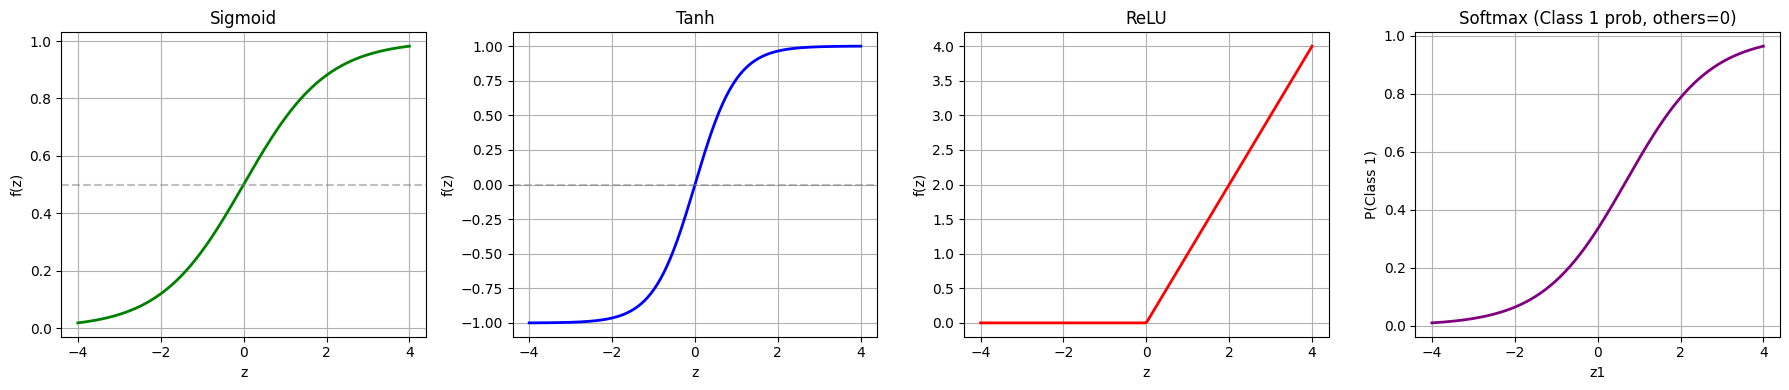

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh_func(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    """Softmax for a single sample across classes."""
    e_z = np.exp(z - np.max(z))  # numerical stability
    return e_z / e_z.sum()

z = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Sigmoid
axes[0].plot(z, sigmoid(z), color='green', linewidth=2)
axes[0].set_title('Sigmoid')
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].grid(True)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Tanh
axes[1].plot(z, tanh_func(z), color='blue', linewidth=2)
axes[1].set_title('Tanh')
axes[1].set_xlabel('z')
axes[1].set_ylabel('f(z)')
axes[1].grid(True)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# ReLU
axes[2].plot(z, relu(z), color='red', linewidth=2)
axes[2].set_title('ReLU')
axes[2].set_xlabel('z')
axes[2].set_ylabel('f(z)')
axes[2].grid(True)

# Softmax (show how output changes for one class as z varies)
z_softmax = np.linspace(-4, 4, 200)
softmax_out = np.array([softmax(np.array([zi, 0, 0]))[0] for zi in z_softmax])
axes[3].plot(z_softmax, softmax_out, color='purple', linewidth=2)
axes[3].set_title('Softmax (Class 1 prob, others=0)')
axes[3].set_xlabel('z1')
axes[3].set_ylabel('P(Class 1)')
axes[3].grid(True)

plt.tight_layout()
plt.show()

<a name="section_4_2"></a>
### 4.2 Basic MLP with Scikit-Learn
We use Scikit-Learn's `MLPClassifier` to create a basic neural network for the Iris dataset.

In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load data
iris = load_iris()
X, y = iris.data, iris.target
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(iris.target_names)} classes")
print(f"Classes: {list(iris.target_names)}")

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the MLP Classifier
# hidden_layer_sizes=(10,) means 1 hidden layer with 10 neurons
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = mlp.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=iris.target_names)}")

Dataset: 150 samples, 4 features, 3 classes
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



<a name="section_4_3"></a>
### 4.3 Deep MLP and Learning Curves
Deep neural networks have multiple hidden layers. Below we create a deeper MLP for the Digits dataset and plot its **Learning Curve** (loss vs. iterations).

Digits Dataset: 1797 samples, 64 features, 10 classes
Deep MLP Test Accuracy on Digits: 96.85%


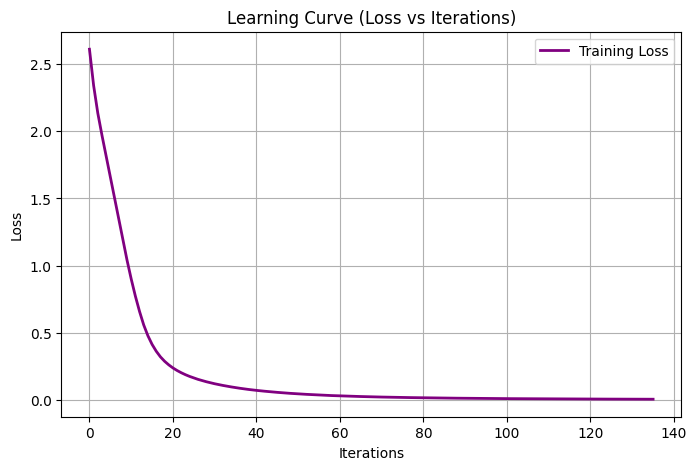

In [3]:
from sklearn.datasets import load_digits

# Load digits dataset (8x8 images of handwritten digits 0-9)
digits = load_digits()
X_dig = digits.data
y_dig = digits.target
print(f"Digits Dataset: {X_dig.shape[0]} samples, {X_dig.shape[1]} features, {len(digits.target_names)} classes")

X_train_dig, X_test_dig, y_train_dig, y_test_dig = train_test_split(
    X_dig, y_dig, random_state=42, test_size=0.3)
scaler_dig = StandardScaler()
X_train_dig_scaled = scaler_dig.fit_transform(X_train_dig)
X_test_dig_scaled = scaler_dig.transform(X_test_dig)

# Deep network: 2 hidden layers with 50 and 25 neurons
deep_mlp = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
deep_mlp.fit(X_train_dig_scaled, y_train_dig)

y_pred_dig = deep_mlp.predict(X_test_dig_scaled)
print(f"Deep MLP Test Accuracy on Digits: {accuracy_score(y_test_dig, y_pred_dig) * 100:.2f}%")

# Plotting the learning curve
plt.figure(figsize=(8, 5))
plt.plot(deep_mlp.loss_curve_, label='Training Loss', color='purple', linewidth=2)
plt.title('Learning Curve (Loss vs Iterations)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

<a name="section_4_4"></a>
### 4.4 Keras Neural Network for Iris Classification
Keras (part of TensorFlow) provides a high-level API for building neural networks. Below we build a simple feedforward network with:
- An input layer matching the 4 Iris features
- A hidden layer with 10 neurons and **ReLU** activation
- An output layer with 3 neurons and **Softmax** activation (one per class)
- **Categorical Cross-Entropy** loss and the **Adam** optimizer

**Parameter Calculation:**
- **Hidden Layer:** Receives 4 inputs. It has 10 neurons. Each neuron has 4 weights and 1 bias. Parameters = $(4 \times 10) + 10 = 50$.
- **Output Layer:** Receives 10 inputs from the hidden layer. It has 3 neurons. Parameters = $(10 \times 3) + 3 = 33$.
- **Total Parameters:** $50 + 33 = 83$.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)


Keras Test Accuracy: 86.67%


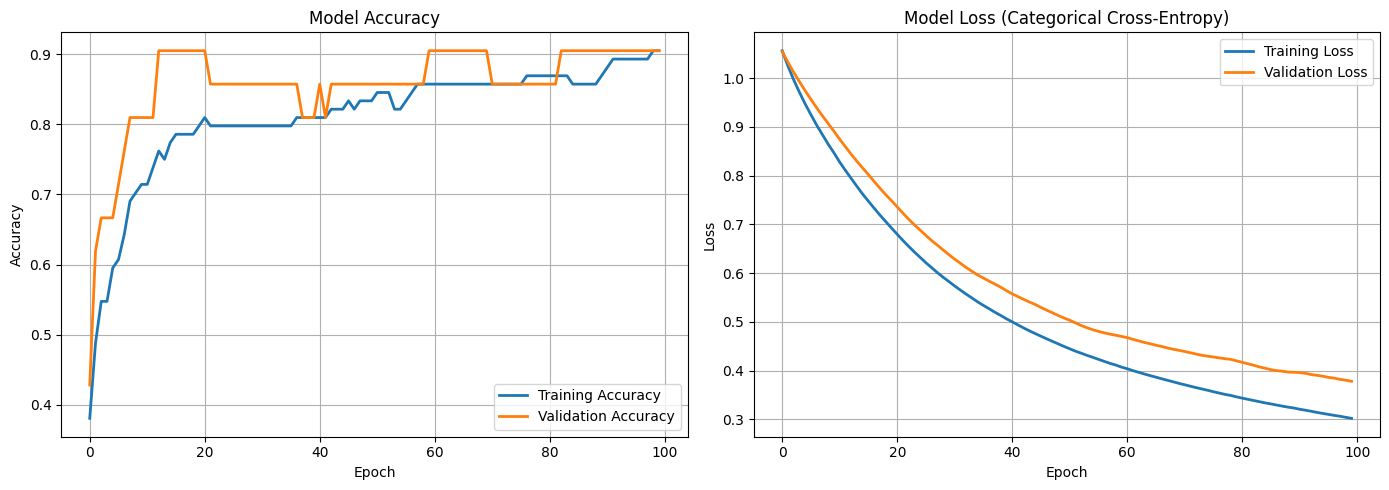


Sample predictions (first 10):
True labels:      [1 0 2 1 1 0 1 2 1 1]
Predicted labels: [1 0 2 1 2 0 1 2 1 1]
Predicted probs (Softmax output for first sample): [0.0558 0.5489 0.3952]


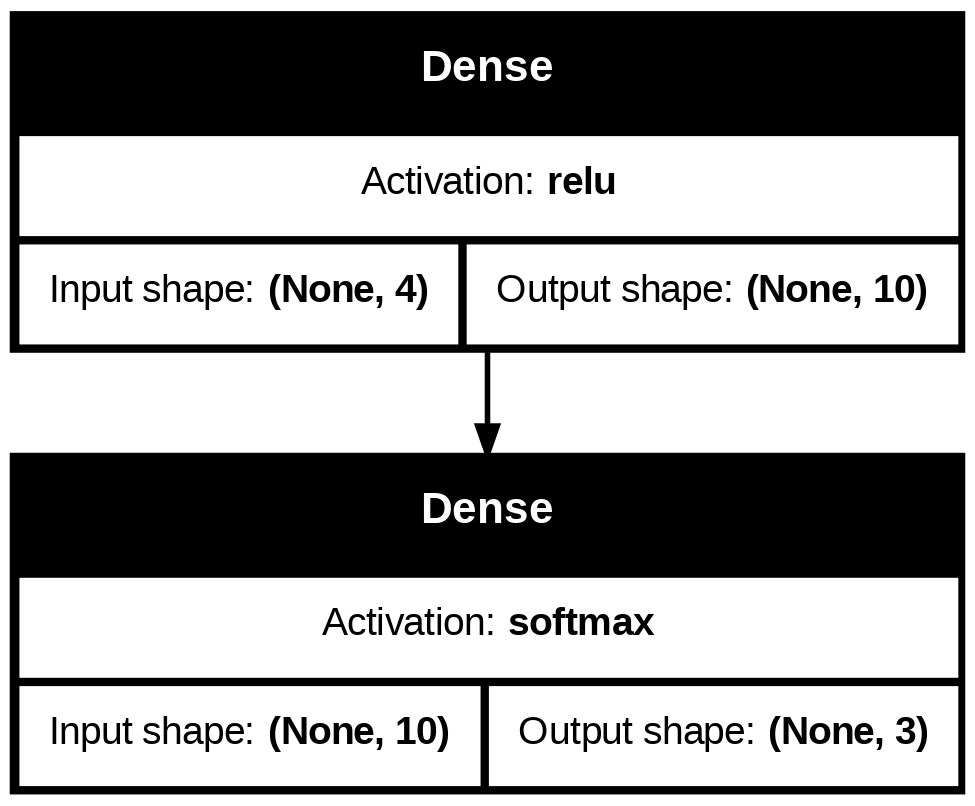

In [4]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load and prepare data
iris = load_iris()
X, y = iris.data, iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode the labels (required for categorical cross-entropy)
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=3)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=3)

# Build the Keras model
model = keras.Sequential([
    keras.layers.Input(shape=(4,)),                                 # Input layer
    keras.layers.Dense(10, activation='relu'),                      # Hidden layer: 10 neurons, ReLU
    keras.layers.Dense(3, activation='softmax')                     # Output layer: 3 neurons, Softmax
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(X_train_scaled, y_train_onehot,
                    epochs=100,
                    batch_size=16,
                    validation_split=0.2,
                    verbose=0)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f"\nKeras Test Accuracy: {test_acc * 100:.2f}%")

# Plot training & validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss (Categorical Cross-Entropy)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Show predictions on test set
y_pred_probs = model.predict(X_test_scaled, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
print(f"\nSample predictions (first 10):")
print(f"True labels:      {y_test[:10]}")
print(f"Predicted labels: {y_pred_classes[:10]}")
print(f"Predicted probs (Softmax output for first sample): {y_pred_probs[0].round(4)}")

# Visualize the model architecture
from tensorflow.keras.utils import plot_model
from IPython.display import display
try:
    img = plot_model(model, show_shapes=True, show_layer_activations=True)
    display(img)
except Exception as e:
    print("Could not plot model:", e)

---
© 2026 Ghassem Tofighi. All rights reserved. Unauthorized reuse or distribution is prohibited.